<a href="https://colab.research.google.com/github/BenziJPCorrales/DATA-433-Indiana-Housing-Prediction/blob/main/ai_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [26]:
#THIS ALL WILL BE CHANGED TO HOUSING DATA FOR FINAL MODEL
abalone = pd.read_csv('https://raw.githubusercontent.com/BenziJPCorrales/DATA-433-Indiana-Housing-Prediction/main/temp_abalone.csv')
abalone = pd.get_dummies(abalone,drop_first=True,prefix="Sex")
X = abalone.drop('Rings',axis=1)
y = abalone[['Rings']]

In [27]:
#training model
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X_train,y_train)
pred = lin_reg.predict(X_test)

In [28]:
#testing model for accuracy
from sklearn.metrics import root_mean_squared_error
r_squared = lin_reg.score(X_test, y_test)

rmse = root_mean_squared_error(y_test, pred)

print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))
#print(lin_reg.coef_)
#print(lin_reg.intercept)


R^2: 0.5368358677048559
RMSE: 2.1686924105556304


In [29]:
#standardization
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
steps = [('scaler', StandardScaler()), ('lin_reg',LinearRegression())]

pipeline = Pipeline(steps)
pipeline.fit(X_train,y_train)
pred = pipeline.predict(X_test)

In [30]:
#testing standardized model for accuracy

r_squared = pipeline.score(X_test, y_test)

rmse = root_mean_squared_error(y_test, pred)

print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R^2: 0.5368358677048563
RMSE: 2.1686924105556296


In [31]:
#regularization
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge

In [32]:
#LASSO
steps = [('scaler', StandardScaler()), ('lasso',Lasso(alpha=0.1))]

pipeline = Pipeline(steps)
pipeline.fit(X_train,y_train)
pred = pipeline.predict(X_test)

In [33]:
#testing lasso model for accuracy
from sklearn.metrics import mean_squared_error, root_mean_squared_error
r_squared = pipeline.score(X_test, y_test)

rmse = root_mean_squared_error(y_test, pred)

# Print the metrics
print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R^2: 0.509181297846414
RMSE: 2.2324978586496944


In [34]:
#RIDGE

steps = [('scaler', StandardScaler()), ('ridge',Ridge(alpha=0.5))]
pipeline = Pipeline(steps)
pipeline.fit(X_train,y_train)
pred = pipeline.predict(X_test)

In [35]:
#testing ridge for accuracy

r_squared = pipeline.score(X_test, y_test)

rmse = root_mean_squared_error(y_test, pred)

# Print the metrics
print("R^2: {}".format(r_squared))
print("RMSE: {}".format(rmse))

R^2: 0.5373220494565083
RMSE: 2.1675538773218044


In [36]:
#cross-validating
from sklearn.model_selection import GridSearchCV

alphas = np.logspace(-3, -1, 50)
params = [{"alpha": alphas}]
n_folds = 6

model = GridSearchCV(Lasso(),params,cv=n_folds,refit=True)
model.fit(X,y)

scores = model.cv_results_["mean_test_score"]
scores_std = model.cv_results_["std_test_score"]

(np.float64(0.001), np.float64(0.1))

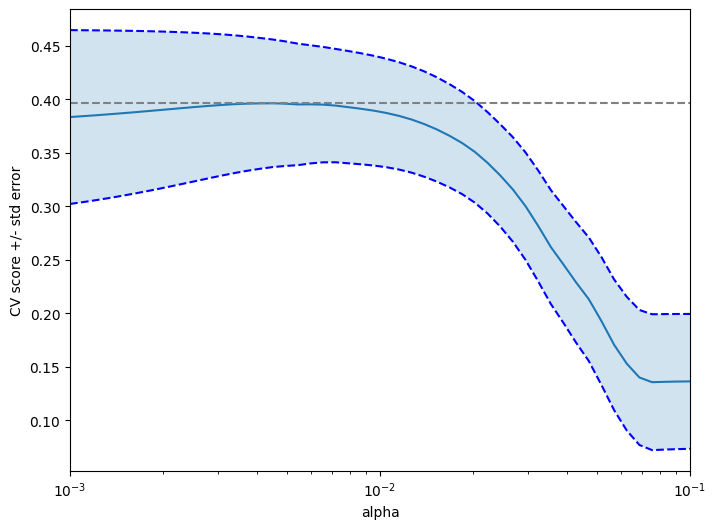

In [37]:
#plotting cross validation

plt.figure().set_size_inches(8, 6)
plt.semilogx(alphas, scores)

std_error = scores_std / np.sqrt(n_folds)

plt.semilogx(alphas, scores + std_error, "b--")
plt.semilogx(alphas, scores - std_error, "b--")

plt.fill_between(alphas, scores + std_error, scores - std_error, alpha=0.2)

plt.ylabel("CV score +/- std error")
plt.xlabel("alpha")
plt.axhline(np.max(scores), linestyle="--", color=".5")
plt.xlim([alphas[0], alphas[-1]])

In [38]:
model.best_score_

np.float64(0.3963432400927607)

In [39]:
model.best_estimator_.alpha

np.float64(0.004498432668969444)